# Criando Custom Dataset:

In [1]:
!ls

Custom_dataset	KWS  model_mfcc_fp16.tflite  output.wav


In [2]:
!pip install flask

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple


In [3]:
import flask
from flask import request, jsonify, render_template_string
import pyaudio
import wave
import numpy as np
from scipy.signal import resample_poly
import os
import time

# --- Constantes do App ---
app = flask.Flask(__name__)
BASE_DIR = 'Custom_dataset'
LABELS = ['go', 'no', 'off', 'on', 'stop', '_silence_', '_unknown_']

# --- Constantes de Áudio (do seu script) ---
FORMAT = pyaudio.paInt16
CHANNELS = 1
RATE = 48000
TARGET_RATE = 16000
CHUNK = 1024
RECORD_SECONDS = 1  # Alterado para 1 segundo
DEVICE_INDEX = 0    # Seu índice de microfone

# --- Interface Web (HTML/JS) ---
# Usamos render_template_string para manter tudo em um único arquivo.
HTML_TEMPLATE = """
<!doctype html>
<html lang="pt-br">
<head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <title>Gravador de Dataset</title>
    <style>
        body { font-family: sans-serif; display: grid; place-items: center; min-height: 90vh; background-color: #f4f4f4; }
        .container { background: #fff; border-radius: 8px; box-shadow: 0 4px 12px rgba(0,0,0,0.1); padding: 2rem; }
        h1 { text-align: center; color: #333; }
        .form-group { margin-bottom: 1.5rem; }
        label { display: block; margin-bottom: 0.5rem; font-weight: bold; }
        select, button {
            width: 100%;
            padding: 0.75rem;
            font-size: 1rem;
            border-radius: 4px;
            border: 1px solid #ccc;
            box-sizing: border-box; /* Importante para o padding não quebrar o layout */
        }
        button {
            background-color: #007bff;
            color: white;
            font-weight: bold;
            border: none;
            cursor: pointer;
            transition: background-color 0.2s;
        }
        button:hover { background-color: #0056b3; }
        button:disabled { background-color: #aaa; cursor: not-allowed; }
        #status {
            text-align: center;
            font-weight: bold;
            margin-top: 1.5rem;
            min-height: 1.2em;
        }
        .status-recording { color: #d9534f; }
        .status-success { color: #5cb85c; }
        .status-error { color: #d9534f; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Gravador de Dataset</h1>
        <div class="form-group">
            <label for="label-select">Selecione a Palavra-Chave:</label>
            <select id="label-select">
                {% for label in labels %}
                    <option value="{{ label }}">{{ label | capitalize }}</option>
                {% endfor %}
            </select>
        </div>
        <button id="record-btn">Gravar 1 Segundo</button>
        <div id="status"></div>
    </div>

    <script>
        document.getElementById('record-btn').addEventListener('click', function() {
            const label = document.getElementById('label-select').value;
            const statusEl = document.getElementById('status');
            const btn = this;

            // Feedback visual
            statusEl.textContent = 'Gravando...';
            statusEl.className = 'status-recording';
            btn.disabled = true;

            // Envia o pedido para o servidor
            fetch('/record', {
                method: 'POST',
                headers: { 'Content-Type': 'application/json' },
                body: JSON.stringify({ label: label })
            })
            .then(response => response.json())
            .then(data => {
                if (data.status === 'success') {
                    statusEl.textContent = `Salvo: ${data.file}`;
                    statusEl.className = 'status-success';
                } else {
                    statusEl.textContent = `Erro: ${data.error}`;
                    statusEl.className = 'status-error';
                }
            })
            .catch(err => {
                statusEl.textContent = 'Erro de conexão: ' + err;
                statusEl.className = 'status-error';
            })
            .finally(() => {
                // Re-habilita o botão após 1 segundo para evitar spam
                setTimeout(() => {
                    btn.disabled = false;
                    if (statusEl.className !== 'status-error') {
                        statusEl.textContent = ''; // Limpa o status
                    }
                }, 1000);
            });
        });
    </script>
</body>
</html>
"""

# --- Funções Auxiliares ---

def create_dataset_dirs():
    """Garante que todos os diretórios de labels existam."""
    os.makedirs(BASE_DIR, exist_ok=True)
    for label in LABELS:
        os.makedirs(os.path.join(BASE_DIR, label), exist_ok=True)
    print(f"Diretórios criados em ./{BASE_DIR}/")

def record_and_save(label):
    """
    Grava 1 segundo de áudio, reamostra e salva no 
    diretório da label correspondente.
    """
    audio = pyaudio.PyAudio()
    
    stream = audio.open(
        format=FORMAT,
        channels=CHANNELS,
        rate=RATE,
        input=True,
        input_device_index=DEVICE_INDEX,
        frames_per_buffer=CHUNK
    )

    frames = []
    for _ in range(0, int(RATE / CHUNK * RECORD_SECONDS)):
        data = stream.read(CHUNK, exception_on_overflow=False)
        frames.append(data)

    # Para a gravação
    stream.stop_stream()
    stream.close()
    sample_width = audio.get_sample_size(FORMAT) # Pega o tamanho antes de terminar
    audio.terminate()

    # Processamento e Resample
    audio_data = np.frombuffer(b''.join(frames), dtype=np.int16)
    resampled_data = resample_poly(audio_data, TARGET_RATE, RATE).astype(np.int16)

    # Salva o arquivo
    # Gera um nome de arquivo único com timestamp
    filename = f"{label}_{int(time.time() * 1000)}.wav"
    filepath = os.path.join(BASE_DIR, label, filename)

    with wave.open(filepath, 'wb') as wf:
        wf.setnchannels(CHANNELS)
        wf.setsampwidth(sample_width)
        wf.setframerate(TARGET_RATE)
        wf.writeframes(resampled_data.tobytes())
    
    return filepath # Retorna o caminho do arquivo salvo

# --- Rotas do Flask ---

@app.route('/')
def index():
    """Serve a página HTML principal."""
    return render_template_string(HTML_TEMPLATE, labels=LABELS)

@app.route('/record', methods=['POST'])
def handle_record():
    """Recebe o POST da web, chama a gravação e retorna o status."""
    try:
        data = request.json
        label = data.get('label')

        if label not in LABELS:
            return jsonify({'status': 'error', 'error': 'Label inválida'}), 400

        # Chama a função principal
        saved_file_path = record_and_save(label)
        
        return jsonify({'status': 'success', 'file': saved_file_path})

    except Exception as e:
        print(f"Erro durante a gravação: {e}")
        return jsonify({'status': 'error', 'error': str(e)}), 500

# --- Execução ---

if __name__ == '__main__':
    create_dataset_dirs() # Cria as pastas 'go', 'no', 'off', etc.
    print(f"Servidor iniciado. Acesse no seu navegador: http://<IP_DA_SUA_PI>:5000")
    # host='0.0.0.0' torna o servidor acessível na sua rede local
    app.run(host='0.0.0.0', port=5000, debug=False)

Diretórios criados em ./Custom_dataset/
Servidor iniciado. Acesse no seu navegador: http://<IP_DA_SUA_PI>:5000
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.0.103:5000
Press CTRL+C to quit
192.168.0.100 - - [06/Nov/2025 15:25:32] "GET / HTTP/1.1" 200 -
192.168.0.100 - - [06/Nov/2025 15:25:32] "GET /favicon.ico HTTP/1.1" 404 -
ALSA lib pcm_dmix.c:999:(snd_pcm_dmix_open) unable to open slave
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.center_lfe
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.side
ALSA lib confmisc.c:1369:(snd_func_refer) Unable to find definition 'cards.0.pcm.hdmi.0:CARD=0,AES0=4,AES1=130,AES2=0,AES3=2'
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5703:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM hdmi
ALSA lib confmisc.c:1369:(snd_func_refer) Unable to find defin

# Fine tunning do modelo:

In [1]:
!ls ../Projects/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/

Custom_dataset	      main_rasp.ipynb  README.md	    testLed.ipynb
custom_dataset.ipynb  models	       requirements-pc.txt
Docs		      notebooks        ruidos


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [5]:
BATCH_SIZE = 32
SAMPLE_RATE = 16000
AUDIO_DURATION_S = 1 # Duração de cada áudio em segundos
SAMPLES_PER_AUDIO = SAMPLE_RATE * AUDIO_DURATION_S

# Parâmetros para STFT
FRAME_LENGTH = 512
FRAME_STEP = 256
N_FFT = 512

# Parâmetros para Mel & MFCC
N_MELS = 128
F_MIN = 20
F_MAX = SAMPLE_RATE / 2
N_MFCCS = 40

AUTOTUNE = tf.data.AUTOTUNE

In [6]:
def get_label(file_path: tf.Tensor) -> tf.Tensor:
    """Extrai o rótulo (label) como um inteiro a partir do caminho do arquivo."""
    parts = tf.strings.split(file_path, '/')
    label_str = parts[-2]
    label_int = tf.argmax(label_str == CLASS_NAMES)
    return tf.cast(label_int, tf.int64)

def decode_audio(file_path: tf.Tensor) -> tf.Tensor:
    """Lê, decodifica, normaliza e garante o comprimento fixo do áudio."""
    audio_binary = tf.io.read_file(file_path)
    audio, sr = tf.audio.decode_wav(audio_binary, desired_channels=1)
    waveform = tf.squeeze(audio, axis=-1)
    waveform = tf.cast(waveform, tf.float32)
    current_len = tf.shape(waveform)[0]

    if current_len < SAMPLES_PER_AUDIO:
        padding = tf.zeros(SAMPLES_PER_AUDIO - current_len, dtype=tf.float32)
        waveform = tf.concat([waveform, padding], 0)
    
    waveform = waveform[:SAMPLES_PER_AUDIO]
    waveform.set_shape([SAMPLES_PER_AUDIO])
    return waveform

# <--- MUDANÇA: Nova função para extrair MFCCs ---
def get_mfccs(waveform: tf.Tensor) -> tf.Tensor:
    """Converte a forma de onda (waveform) de áudio em MFCCs."""
    # 1. Primeiro, calculamos o log-mel espectrograma, que é a base para os MFCCs.
    stft = tf.signal.stft(
        waveform,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=N_FFT
    )
    spectrogram = tf.abs(stft)
    mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MELS,
        num_spectrogram_bins=stft.shape[-1],
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz=F_MIN,
        upper_edge_hertz=F_MAX
    )
    mel_spectrogram = tf.tensordot(spectrogram, mel_filterbank, 1)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    # 2. Agora, calculamos os MFCCs a partir do log-mel espectrograma.
    # A função do TensorFlow já aplica a DCT (Transformada Discreta de Cosseno).
    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrogram)

    # 3. Mantemos apenas os primeiros N_MFCCS coeficientes, que são os mais informativos.
    mfccs = mfccs[..., :N_MFCCS]
    
    # 4. Adiciona uma dimensão de "canal" para compatibilidade com CNNs.
    # O formato final será (tempo, n_mfccs, canais=1)
    return tf.expand_dims(mfccs, axis=-1)


def process_path(file_path: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    """Função principal que combina todas as etapas de processamento."""
    label = get_label(file_path)
    waveform = decode_audio(file_path)
    # <--- MUDANÇA: Chamando a nova função get_mfccs ---
    mfccs = get_mfccs(waveform)
    return mfccs, label

# --- 4. Função para Criar o Dataset Final ---

def create_dataset(data_path: Path, shuffle: bool = True):
    """Cria um tf.data.Dataset otimizado a partir de um diretório."""
    ds = tf.data.Dataset.list_files(str(data_path / '*/*.wav'), shuffle=shuffle)
    ds = ds.map(process_path, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

In [7]:
dataset_path = Path('../Projects/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/Custom_dataset')

In [8]:
train_dir = dataset_path / 'train'
val_dir = dataset_path / 'validation'
test_dir = dataset_path / 'test'

In [9]:
CLASS_NAMES = np.array(sorted([item.name for item in train_dir.glob('*') if item.is_dir()]))
print(f"Classes encontradas: {CLASS_NAMES}")

print("\nCriando o dataset de treinamento...")
train_ds = create_dataset(train_dir, shuffle=True)

print("Criando o dataset de validação...")
val_ds = create_dataset(val_dir, shuffle=False)

print("Criando o dataset de teste...")
test_ds = create_dataset(test_dir, shuffle=False)

Classes encontradas: ['_silence_' '_unknown_' 'go' 'no' 'off' 'on' 'stop']

Criando o dataset de treinamento...


I0000 00:00:1762452518.743476   70700 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9792 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


Criando o dataset de validação...
Criando o dataset de teste...


In [10]:
train_ds, val_ds, test_ds

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 61, 40, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 61, 40, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 61, 40, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

In [11]:
print("\n--- Verificação do Pipeline ---")

for mfccs, labels in train_ds.take(1):
    print(f"Shape do lote de MFCCs: {mfccs.shape}")
    print(f"Shape do lote de labels: {labels.shape}")
    print(f"Tipo de dado dos MFCCs: {mfccs.dtype}")
    print(f"Tipo de dado dos labels: {labels.dtype}")
    
    first_mfcc = mfccs[0]
    print(f"Shape de um único MFCC: {first_mfcc.shape}")
    
    first_label = labels[0]
    print(f"Label do primeiro item do lote: {first_label.numpy()} ({CLASS_NAMES[first_label]})")



--- Verificação do Pipeline ---
Shape do lote de MFCCs: (32, 61, 40, 1)
Shape do lote de labels: (32,)
Tipo de dado dos MFCCs: <dtype: 'float32'>
Tipo de dado dos labels: <dtype: 'int64'>
Shape de um único MFCC: (61, 40, 1)
Label do primeiro item do lote: 0 (_silence_)


2025-11-06 15:08:42.834021: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Formato (shape) do lote de MFCCs: (32, 61, 40, 1)
Formato (shape) do lote de rótulos: (32,)


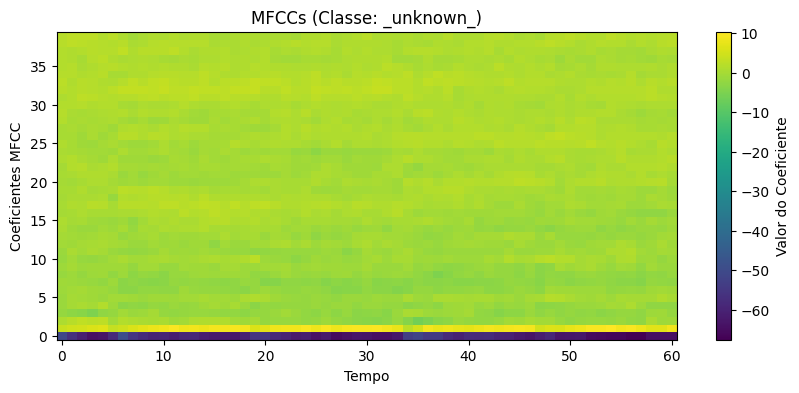

In [12]:
for mfccs, labels in train_ds.take(1):
    input_shape = mfccs.shape[1:]
    print(f"\nFormato (shape) do lote de MFCCs: {mfccs.shape}")
    print(f"Formato (shape) do lote de rótulos: {labels.shape}")
    
    plt.figure(figsize=(10, 4))
    # Não aplicamos mais o log aqui, pois os MFCCs já estão processados.
    plt.imshow(mfccs[0, :, :, 0].numpy().T, aspect='auto', origin='lower')
    plt.title(f"MFCCs (Classe: {CLASS_NAMES[labels[0]]})")
    plt.ylabel("Coeficientes MFCC")
    plt.xlabel("Tempo")
    plt.colorbar(label='Valor do Coeficiente')
    plt.show()
    break

In [13]:
base_model_path = '../Projects/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/models/model_mfcc_aug.keras'

In [14]:
model = tf.keras.models.load_model(base_model_path)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 61, 40, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 61, 40, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 61, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 20, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 15, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,147,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,882,207 (14.81 MB)

 Trainable params: 1,293,641 (4.93 MB)

 Non-trainable params: 1,282 (5.01 KB)

 Optimizer params: 2,587,284 (9.87 MB)

In [15]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)

In [16]:
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('../Projects/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/models/model_mfcc_finetuned.keras', monitor='val_loss', save_best_only=True)
]

In [18]:
history = model.fit(train_ds, validation_data=val_ds, callbacks=callbacks, epochs=1000, verbose=1)

Epoch 1/1000


2025-11-06 15:08:57.579271: I external/local_xla/xla/service/service.cc:163] XLA service 0x798dc4016e90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-06 15:08:57.579282: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-11-06 15:08:57.614777: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-06 15:08:57.839385: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-11-06 15:08:57.955062: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-06 15:08:57.955092: I e

 1/20 ━━━━━━━━━━━━━━━━━━━━ 1:27 5s/step - accuracy: 0.9062 - loss: 0.2329

I0000 00:00:1762452541.058861   70832 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-11-06 15:09:01.410281: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-06 15:09:01.410308: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-06 15:09:01.636954: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2487', 4 bytes s

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8429 - loss: 0.9651

2025-11-06 15:09:04.477852: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-06 15:09:04.688847: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_201', 16 bytes spill stores, 16 bytes spill loads



20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 222ms/step - accuracy: 0.8317 - loss: 1.0589 - val_accuracy: 0.7571 - val_loss: 1.7715
Epoch 2/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8333 - loss: 0.9516 - val_accuracy: 0.7667 - val_loss: 1.5374
Epoch 3/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8460 - loss: 0.8778 - val_accuracy: 0.7905 - val_loss: 1.3519
Epoch 4/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8635 - loss: 0.7951 - val_accuracy: 0.8000 - val_loss: 1.2018
Epoch 5/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8444 - loss: 0.7834 - val_accuracy: 0.8190 - val_loss: 1.0844
Epoch 6/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8635 - loss: 0.7618 - val_accuracy: 0.8286 - val_loss: 1.0007
Epoch 7/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8635 - loss: 0.7196 - val_accuracy: 0.8381 - val_loss: 0.9281
Epoch 8/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8778 - loss: 0.7346 - val_accuracy: 0.8476 - val_

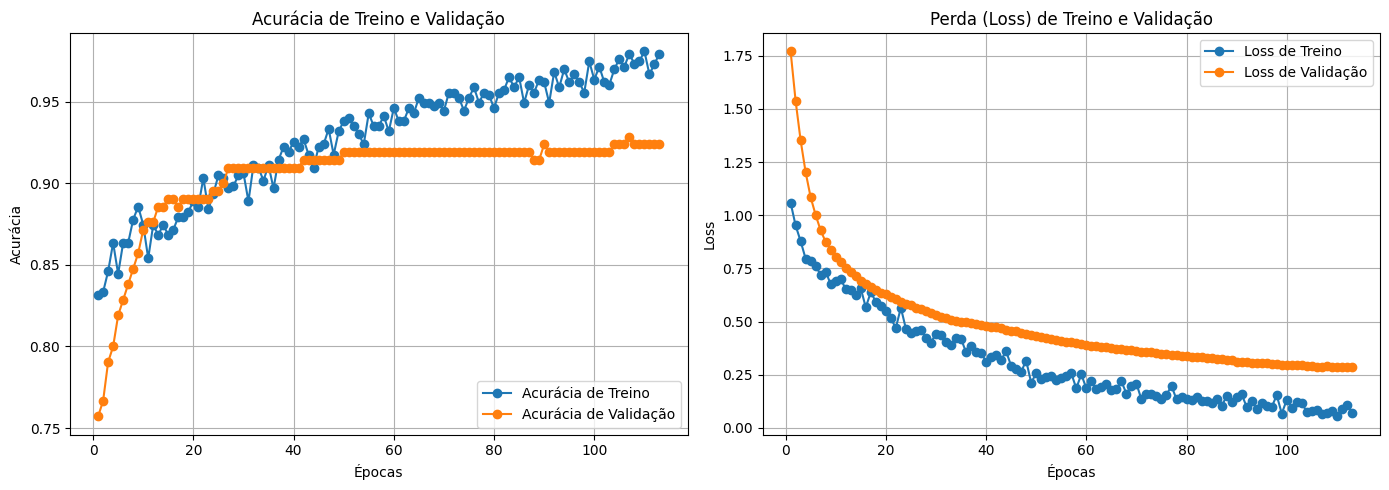

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [20]:
y_pred_probs = model.predict(test_ds)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.concatenate([y for x, y in test_ds], axis=0)

print("\n--- Relatório de Classificação ---")
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)
print(report)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step

--- Relatório de Classificação ---
              precision    recall  f1-score   support

   _silence_       0.88      0.97      0.92        30
   _unknown_       0.88      0.97      0.92        30
          go       0.93      0.90      0.92        30
          no       0.96      0.90      0.93        30
         off       1.00      0.83      0.91        30
          on       0.91      0.97      0.94        30
        stop       0.97      0.97      0.97        30

    accuracy                           0.93       210
   macro avg       0.93      0.93      0.93       210
weighted avg       0.93      0.93      0.93       210



2025-11-06 15:09:30.176064: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



--- Matriz de Confusão ---


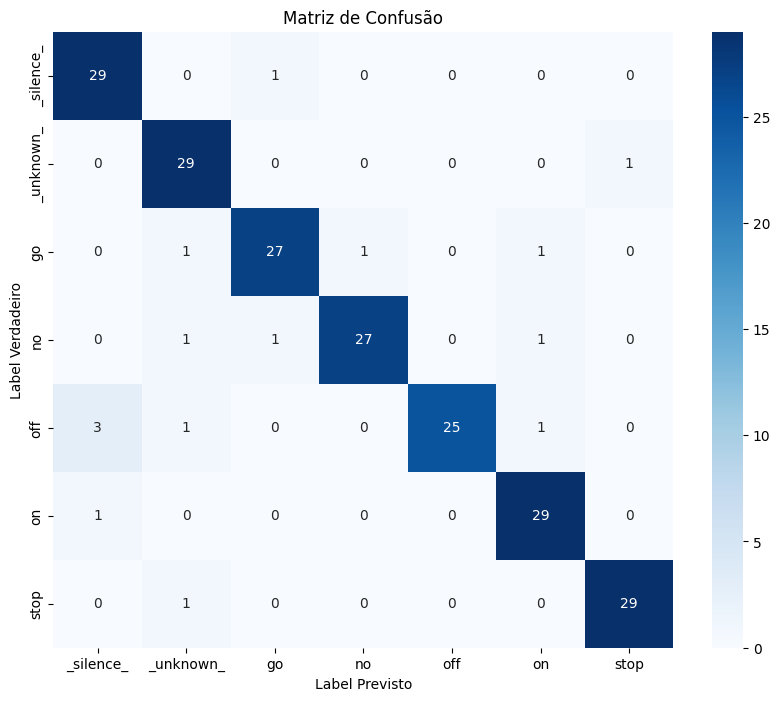

In [21]:
print("\n--- Matriz de Confusão ---")
cm = confusion_matrix(y_true_indices, y_pred_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()


In [25]:
keras_model = tf.keras.models.load_model("/home/rolds/Documents/Projects/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/models/model_mfcc_finetuned.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

print("\nIniciando conversão com quantização Float16...")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model_fp16 = converter.convert()

with open("/home/rolds/Documents/Projects/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/models/model_mfcc_finetuned_fp16.tflite", 'wb') as f:
    f.write(tflite_model_fp16)
print(f"Modelo com Float16 Quantization salvo em /home/rolds/Documents/Projects/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/models/model_mfcc_finetuned_fp16.tflite")


Iniciando conversão com quantização Float16...
INFO:tensorflow:Assets written to: /tmp/tmpis73zjd_/assets


INFO:tensorflow:Assets written to: /tmp/tmpis73zjd_/assets


Saved artifact at '/tmp/tmpis73zjd_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 61, 40, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  133652072954368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133652072948208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133652071805024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133652072950496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133652072950672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133656391521680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133652606044464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133652606042352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133656166421376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133652606043408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133652606052032: 

W0000 00:00:1762452693.544302   70700 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1762452693.544314   70700 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-06 15:11:33.544393: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpis73zjd_
2025-11-06 15:11:33.545326: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-06 15:11:33.545329: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpis73zjd_
2025-11-06 15:11:33.553165: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-06 15:11:33.602007: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpis73zjd_
2025-11-06 15:11:33.613320: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 68928 microseconds.
